# Analyse Comportementale des Achats en Supermarché

## Contexte & Objectifs

Ce notebook présente une analyse exploratoire des données de ventes d'un supermarché,
basée sur le dataset mis à notre disposition.

L'objectif est de mieux comprendre les **habitudes d'achat des clients** à travers plusieurs axes d'analyse :

-  **Fidélité produit** — Quels produits sont les plus achetés ? ajoutés en prémier dans le panier et les plus réachetés 
-  **Temporel** — Quand les clients passent-ils leurs commandes ? (jour, heure)
-  **Catégoriel** — Quels rayons et départements sont les plus populaires ?
-  **Comportement client** — Fréquence de commande, taille du panier moyen

---

##  Données utilisées

| Fichier | Description |
|---|---|
| `aisles.csv` | Rayons du supermarché |
| `departments.csv` | Départements / catégories |
| `products.csv` | Catalogue des produits |
| `orders.csv` | Historique des commandes |
| `order_products.csv` | Produits contenus dans chaque commande |

---

## 1. Chargement des données

In [31]:
import pandas as pd
aisles_dataFrame = pd.read_csv("data/aisles.csv" ,dtype={
                "aisle_id": "int64",
                "aisle" :"str",
})
departement_dataframe = pd.read_csv("data/departments.csv", dtype={
                "department_id" :"int64",
                "department": "str"

})
product_dataframe = pd.read_csv("data/products.csv",dtype={
                "product_id"   : "int64",
                "product_name" :"str",
                "aisle_id"     :"int64",
                "department_id":"int64"
})
order_dataframe = pd.read_csv("data/orders.csv",dtype={
                "order_id" :"int64",
                "user_id":  "int64",
                "eval_set" :"str",
                "order_number" :"int64",
                "order_dow" : "int64",
                "order_hour_of_day" :"int64",
                "days_since_prior_order" : "float64"
})

order_product_dataframe = pd.read_csv("data/order_products.csv",dtype={
                "order_id" :"int64",
                "product_id" :"int64",
                "add_to_cart_order" :"int64",
                "reordered"  : "int64"
})


## 2. Quels sont les produits les plus vendus et à quel rayon appartiennent ils ?

Pour répondre à cette question, nous croisons les données de **produits**, de **rayons** et de **commandes**
afin d'identifier les articles ayant généré le plus grand nombre de ventes sur l'ensemble de la période et les rayaons auxquels ils appartiennent.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sb

PRODUCT_NAME_ID = product_dataframe[["product_id","product_name","aisle_id"]].drop_duplicates()
ORDER_PRODUCT = order_product_dataframe[["product_id","order_id","reordered"]].drop_duplicates()
PRODUCT_AND_AISLE = PRODUCT_NAME_ID.merge(aisles_dataFrame,on="aisle_id",how="inner").drop(columns="aisle_id")

# Jointure : commandes + produits pour obtenir un historique complet
ORDER_PRODUCT_DATA_FRAME = order_dataframe.merge(ORDER_PRODUCT,how='inner',on="order_id").merge(
            PRODUCT_AND_AISLE,on="product_id",how='inner'
             ).drop(columns=["days_since_prior_order", "eval_set"])

# Agrégation : comptage des ventes par produit
Result = ORDER_PRODUCT_DATA_FRAME.groupby("product_name",as_index=False).agg(
    Nombre_de_vente  = pd.NamedAgg("order_id","count"),
    rayon = pd.NamedAgg("aisle","first")
).sort_values(by='Nombre_de_vente', ascending=False).reset_index()

# Sélection du Top 20
data = Result.drop_duplicates().head(20).reset_index()
data.to_csv('output/les_produit_les_plus_vendus.csv',index=False)



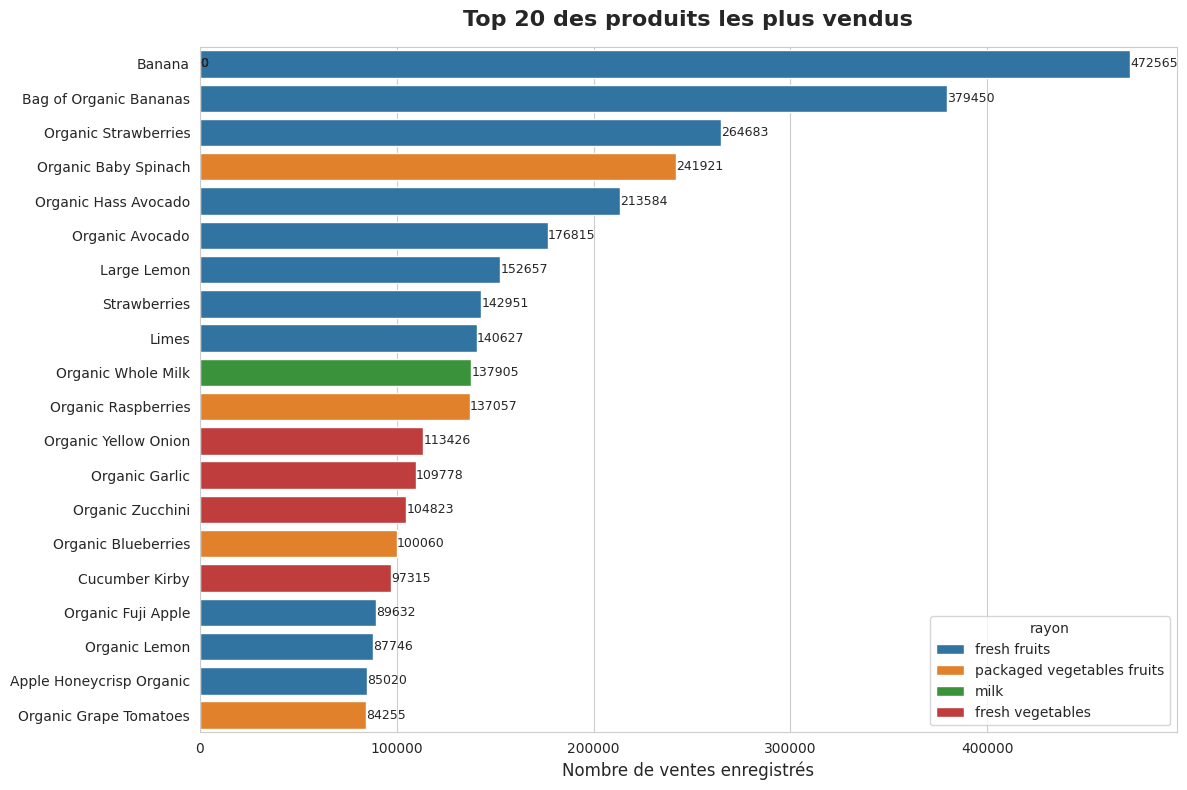

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
sb.set_style("whitegrid")

sb.barplot(x="Nombre_de_vente", y="product_name", data=data,hue="rayon",legend="auto")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=9)

ax.set_title("Top 20 des produits les plus vendus", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Nombre de ventes enregistrés", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Observations
- Les produits les plus commandés appartiennent majoritairement au rayon **fresh fruits,packaged vegetables fruits et milk**.
- La **banane** arrive en tête, loin devant les autres.

## 3. Quels  sont les articles les plus ajoutés en prémier  dans le panier <br> et à quel rayon appartiennent ils?
Le **premier article ajouté au panier** reflète souvent l'intention principale
d'achat du client. <br>
 Nous identifions ici les produits systématiquement choisis
en premier, ce qui peut révéler des **produits privilégié** dans le comportement d'achat.

In [34]:
ORDER_PRODUCT_PRODUCT = order_product_dataframe.merge(
          PRODUCT_AND_AISLE,how="inner",on='product_id'
        ).drop(columns= ["reordered"])

ITEMS_PUT_IN_FIRST =  ORDER_PRODUCT_PRODUCT[ORDER_PRODUCT_PRODUCT["add_to_cart_order"] ==1]

RES = ITEMS_PUT_IN_FIRST.groupby("product_name",as_index=False).agg(
            Occurences = pd.NamedAgg("add_to_cart_order","count"),
            rayon = pd.NamedAgg("aisle","first")
        ).sort_values(by="Occurences",ascending=False)

RES.head(20).to_csv('output/Top_20_des_produits_ajoutes_en premier_dans_le_panier.csv',index=False)

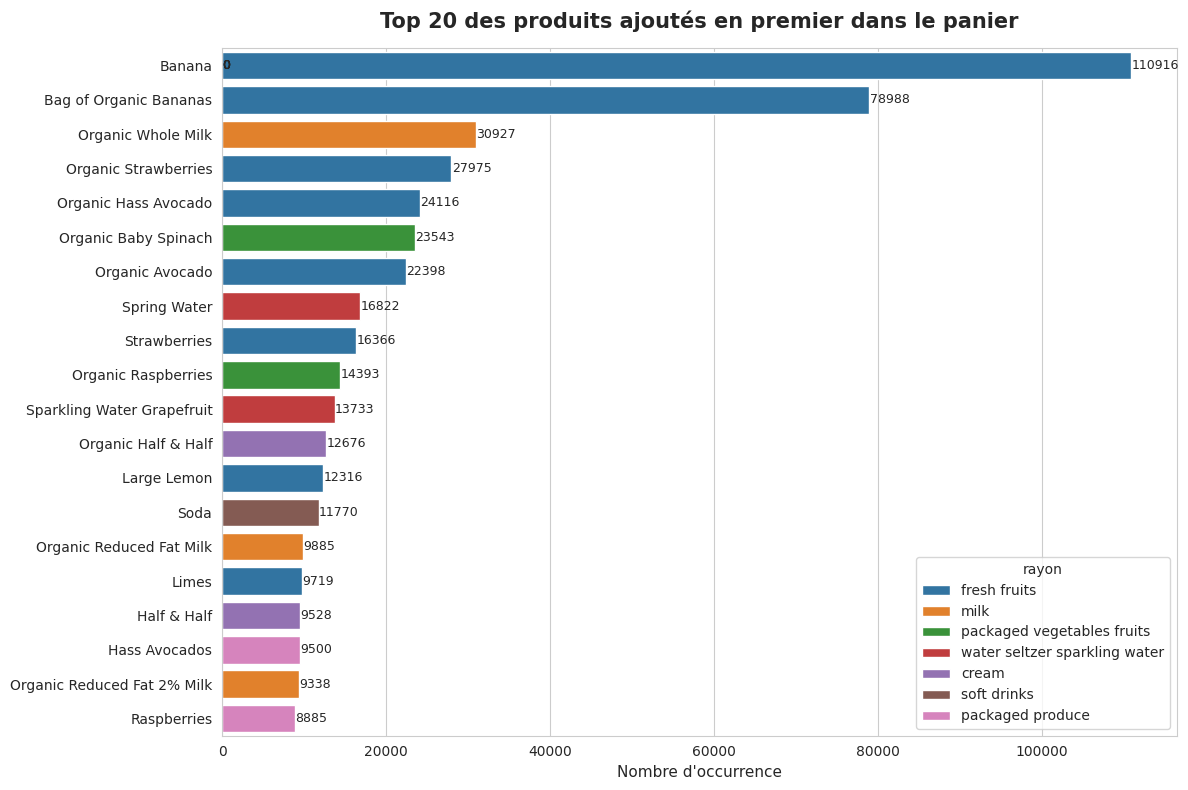

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))
sb.set_style("whitegrid")


sb.barplot(x="Occurences", y="product_name",data=RES.head(20),width=0.8, ax=ax,hue="rayon")

# Valeurs sur les barres
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=9)

ax.set_title("Top 20 des produits ajoutés en premier dans le panier",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Nombre d'occurrence", fontsize=11)
ax.set_ylabel("")
# ax.legend([], [], frameon=False)

plt.tight_layout()
plt.show()

### Observations
- On retrouve des **produits identiques au Top 20 des plus vendus**,
  ce qui confirme leur rôle central dans les habitudes d'achat.
- Ces articles peuvent être considérés comme des **produits à priviliégier**,
  idéaux pour des stratégies de placement ou de promotion.

# 4-Quels sont les  produits qui ont été les plus réachetés ?
**L'article le plus réacheté** reflète le gout du client. <br>
Nous identifions ici les produits ayant fait objet d'un nombre important de réachat 
,ce qui peut révéler des **produits privilégiés** dans l'habitude d'achat.

In [36]:
ORDER_PRODUCT_DATA_FRAME1 = ORDER_PRODUCT_DATA_FRAME[ORDER_PRODUCT_DATA_FRAME["reordered"] == 1]
Result_data = ORDER_PRODUCT_DATA_FRAME1.groupby("product_name",as_index=False).agg(
    Nombre_de_vente = pd.NamedAgg("order_id","count"),
    rayon = pd.NamedAgg("aisle","first")
).sort_values(by='Nombre_de_vente', ascending=False).reset_index()
Result_data.head(20).to_csv('output/Top_20_des_produits_les_plus_rachetés.csv',index=False)


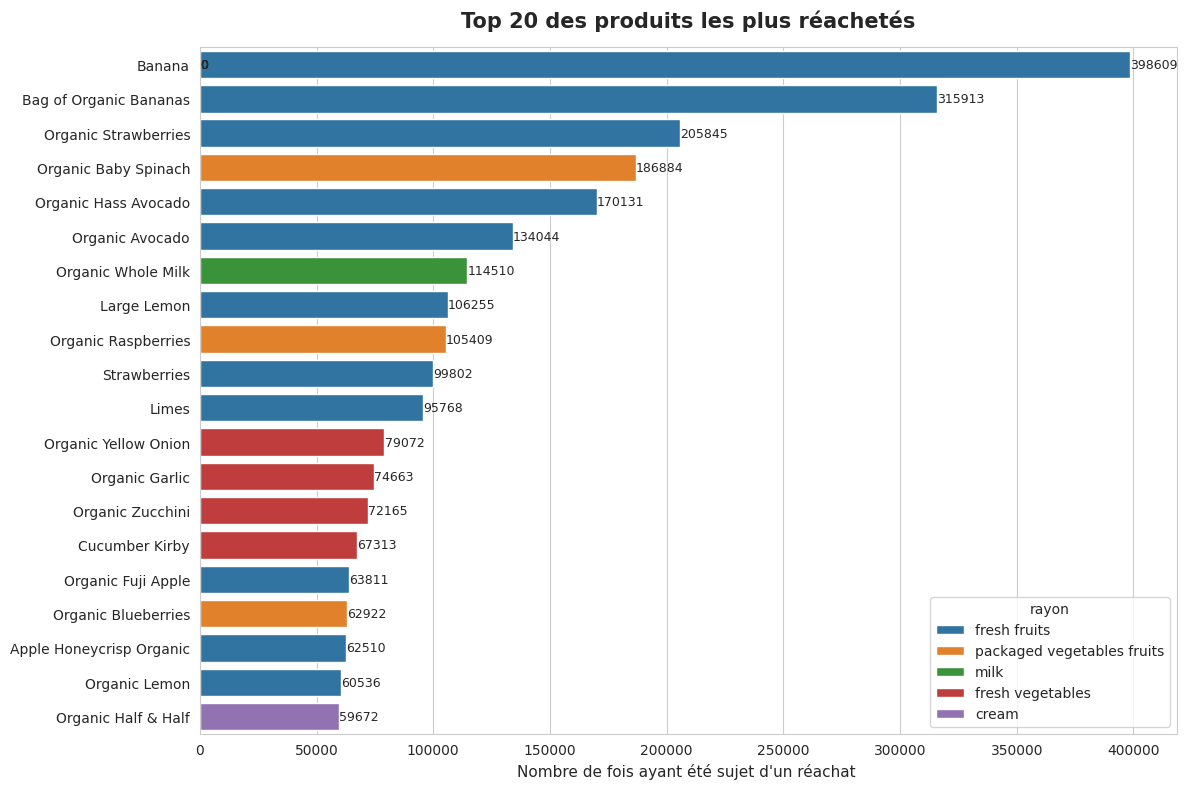

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
sb.set_style("whitegrid")
sb.barplot(x="Nombre_de_vente", y="product_name",data=Result_data.head(20),hue="rayon",width=0.8, ax=ax)

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=9)
ax.set_title("Top 20 des produits les plus réachetés",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Nombre de fois ayant été sujet d'un réachat ", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Observations
- On retrouve des **produits identiques au Top 20 des plus ajoutés en premier dans le panier et les plus vendus**,ce qui confirme nos analyses précédentes.

## 5. Quand les clients passent-ils leurs commandes ?

Nous analysons ici les habitudes temporelles des clients selon **deux axes** :
- Le **jour de la semaine**
- L'**heure de la journée**

In [38]:
# Déterminer le nombre de commandes par jour 
order_dataframe.dropna(subset=["order_dow"],inplace=True)
ORDER_DATA_PER_DAYS = order_dataframe.groupby("order_dow",as_index=False).agg(
    Orders   = pd.NamedAgg("order_id","count")
)
# changer les chiffres de order_dow par les nom exactes des jours
DAYS = pd.DataFrame({ "number": [0,1,2,3,4,5,6], "day":["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
})
ORDER_DATA_PER_DAYS['day'] = DAYS.loc[ORDER_DATA_PER_DAYS["order_dow"],"day"]

# Déterminer les commandes par heure
ORDER_DATA_PER_HOUR = order_dataframe.groupby("order_hour_of_day",as_index=False).agg(
    Orders   = pd.NamedAgg("order_id","count")
)
ORDER_DATA_PER_HOUR.to_csv('output/Nombres_de vente_par_heure.csv')
ORDER_DATA_PER_DAYS.to_csv('output/Nombres_de_ventes_par_jour.csv')

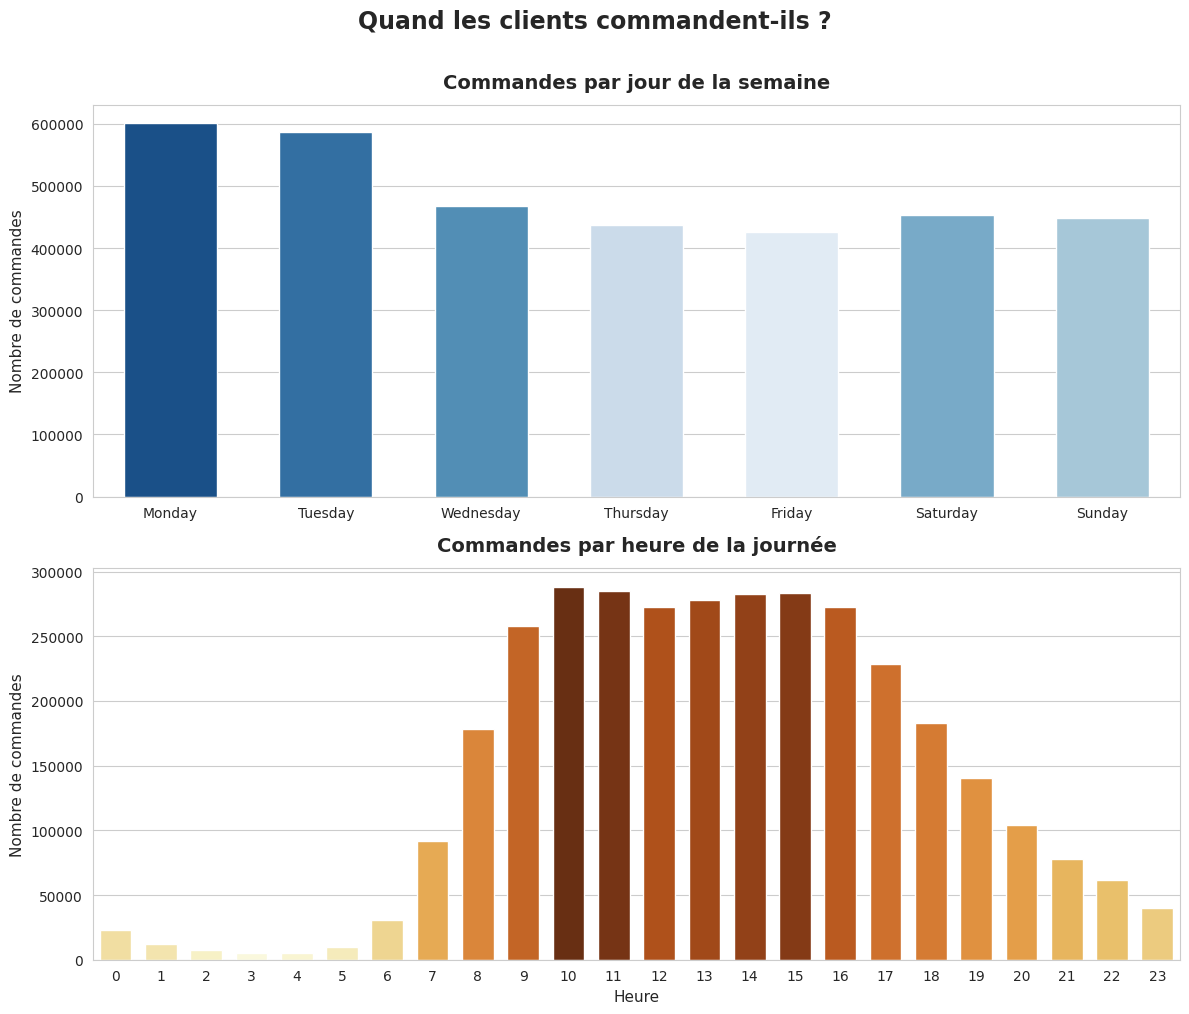

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
sb.set_style("whitegrid")

# Graphique 1 : Par jour 
palette_jours = sb.color_palette("Blues", n_colors=7)

sb.barplot(
    x="day", y="Orders",
    data=ORDER_DATA_PER_DAYS.sort_values("order_dow"),
    palette=palette_jours,
    width=0.6,
    ax=ax1,
    hue="Orders"
)
ax1.set_title("Commandes par jour de la semaine", fontsize=14, fontweight="bold", pad=12)
ax1.set_xlabel("")
ax1.set_ylabel("Nombre de commandes", fontsize=11)
ax1.legend([], [], frameon=False)

# Graphique 2 : Par heure 
palette_heures = sb.color_palette("YlOrBr", n_colors=24)

sb.barplot(
    x="order_hour_of_day", y="Orders",
    data=ORDER_DATA_PER_HOUR,  
    palette=palette_heures,
    width=0.7,
    ax=ax2,
    hue="Orders"
)
ax2.set_title("Commandes par heure de la journée", fontsize=14, fontweight="bold", pad=12)
ax2.set_xlabel("Heure", fontsize=11)
ax2.set_ylabel("Nombre de commandes", fontsize=11)
ax2.legend([], [], frameon=False)

# Mise en forme globale 
fig.suptitle("Quand les clients commandent-ils ?", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Observations

####  Par jour
- Les commandes sont concentrées en **début de semaine**, avec un pic le **lundi et Mardi**.
- La fréquence baisse progressivement en **milieu de semaine** (mercredi, jeudi et vendredi) puis reprend sa progression en weekend.
- Cela suggère que les clients planifient leurs achats en **début ou fin de week-end**.

#### Par heure
- L'activité démarre vers **8h** et atteint son pic entre **10h et 16**.
- Les commandes chutent significativement après **18h**.
- Très peu de commandes sont passées la **nuit (0h - 6h)**.

---
>  **Insight clé** : La plage horaire **10h-16h en début de semaine*(lundi et mardi)*
> concentre le plus grand volume de commandes 

# 6 les rayons et départements les plus rentables
ous analysons ici les habitudes Catégoriel des clients selon **deux axes** :
- Les **rayons dans lesquels sont logés les articles**
- Les **département auxquels appartiennent les produits**

In [40]:
jointure_rayon_produit_commande_produit = product_dataframe.merge(aisles_dataFrame,on="aisle_id",how="inner").merge(
    order_product_dataframe,on='product_id',how="inner")
commande_par_rayon =  jointure_rayon_produit_commande_produit.groupby('aisle').agg(
     nombre_de_ventes = pd.NamedAgg('order_id','count')
).sort_values(by="nombre_de_ventes",ascending=False).head(30)


jointure_departement_produit_commande_produit = product_dataframe.merge(departement_dataframe,on="department_id",how="inner").merge(
    order_product_dataframe,on='product_id',how="inner")
commande_par_departemet =  jointure_departement_produit_commande_produit.groupby('department').agg(
     nombre_de_ventes = pd.NamedAgg('order_id','count')
).sort_values(by="nombre_de_ventes",ascending=False)

commande_par_rayon.to_csv("output/les_rayons_les_plus_rentables.csv")
commande_par_departemet.to_csv("output/les_departements_les_plus_popuaire.csv")


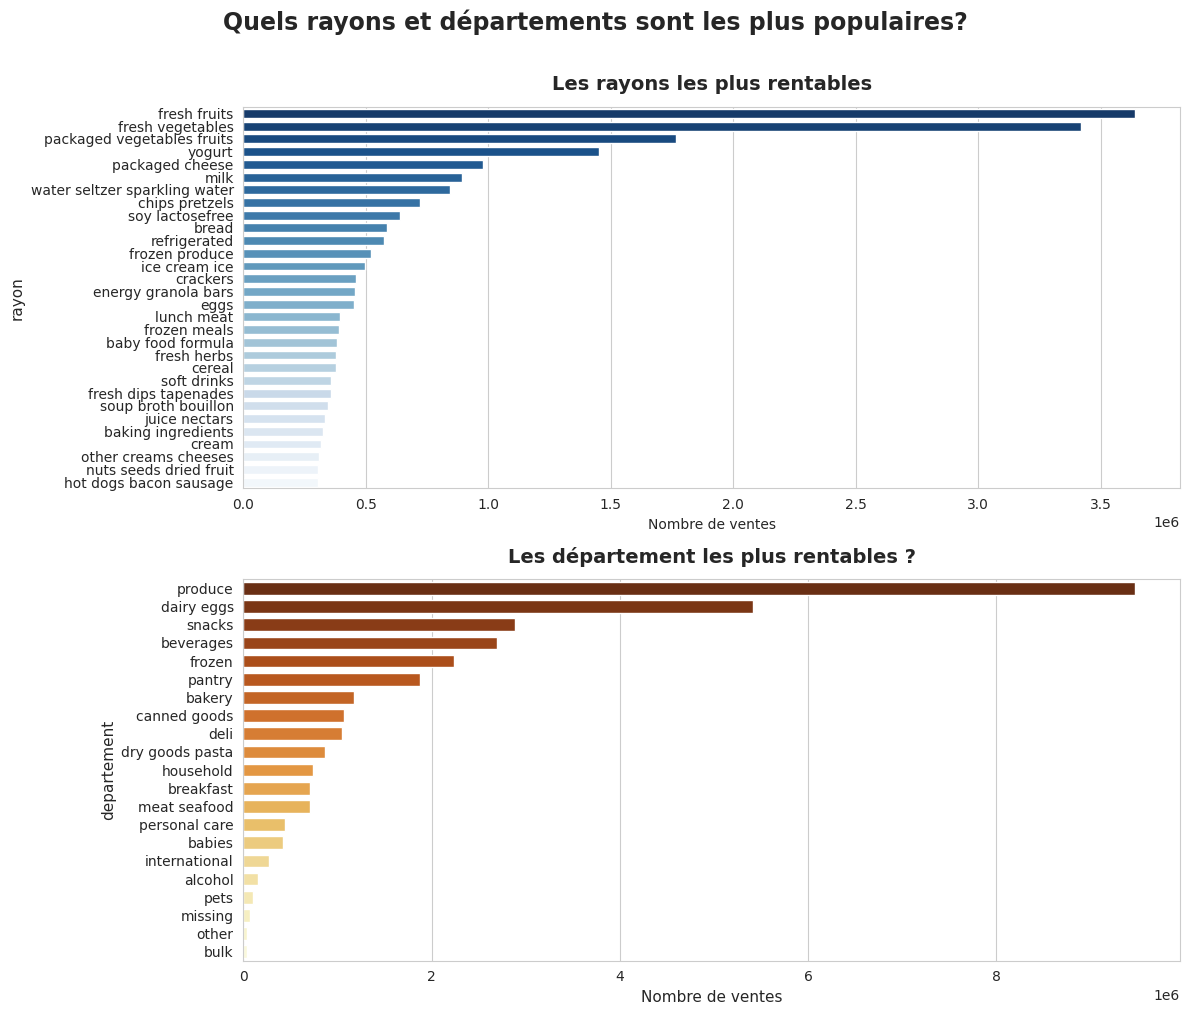

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
sb.set_style("whitegrid")

# Graphique 1 : Par jour 
palette_jours = sb.color_palette("Blues", n_colors=30)

sb.barplot(
    x="nombre_de_ventes", y="aisle",
    data=commande_par_rayon,
    palette=palette_jours,
    width=0.7,
    ax=ax1,
    hue="nombre_de_ventes"
)
ax1.set_title("Les rayons les plus rentables", fontsize=14, fontweight="bold", pad=12)
ax1.set_xlabel("Nombre de ventes")
ax1.set_ylabel("rayon", fontsize=11)
ax1.legend([], [], frameon=False)

# Graphique 2 : Par heure 
palette_heures = sb.color_palette("YlOrBr", n_colors=21)

sb.barplot(
    x="nombre_de_ventes", y="department",
    data=commande_par_departemet,  
    palette=palette_heures,
    width=0.7,
    ax=ax2,
    hue="nombre_de_ventes"
)
ax2.set_title("Les département les plus rentables ?", fontsize=14, fontweight="bold", pad=12)
ax2.set_xlabel("Nombre de ventes", fontsize=11)
ax2.set_ylabel("departement", fontsize=11)
ax2.legend([], [], frameon=False)

# Mise en forme globale 
fig.suptitle("Quels rayons et départements sont les plus populaires?", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Observations
- On retrouve les **fruit frais** à la tete des rayons les plus rentable,cela s'explique par la propondérance de ses articles dans le top des produits les plus prisés par les consommateurs. <br>Cela sugère une attention particulière sur le ravitaillement pour éviter toute rupture de stock!!  
- On retrouve au sommet des département les plus rentables la catégorie **Produce** 

## 7.  Combien d'articles les clients achètent-ils par commande ?

Nous analysons ici la **taille des paniers** en calculant le nombre d'articles
par commande.<br> Les indicateurs clés (minimum, moyenne, maximum) donnent une
première vision de la distribution des achats.

In [42]:
#Agrégation: Comptage d'article par commandes 
ITEMS_BUY_PEOPLE = ORDER_PRODUCT_DATA_FRAME.groupby("order_id").agg(
    NUMBER_OF_ITEMS   = pd.NamedAgg("product_id","count")
).sort_values(by='NUMBER_OF_ITEMS', ascending=False)
# Calcul des indicateurs statistiques clés
Moy = int(ITEMS_BUY_PEOPLE["NUMBER_OF_ITEMS"].mean())
Max = int(ITEMS_BUY_PEOPLE["NUMBER_OF_ITEMS"].max())
Min = int(ITEMS_BUY_PEOPLE["NUMBER_OF_ITEMS"].min())
# Mise en forme pour visualisation
Result = pd.DataFrame({"colonne" : ["Maximum","Moyenne","Minimum"], "valeur" :[Max,Moy,Min]})
Result.to_csv("output/taille_du_panier_moyen.csv")



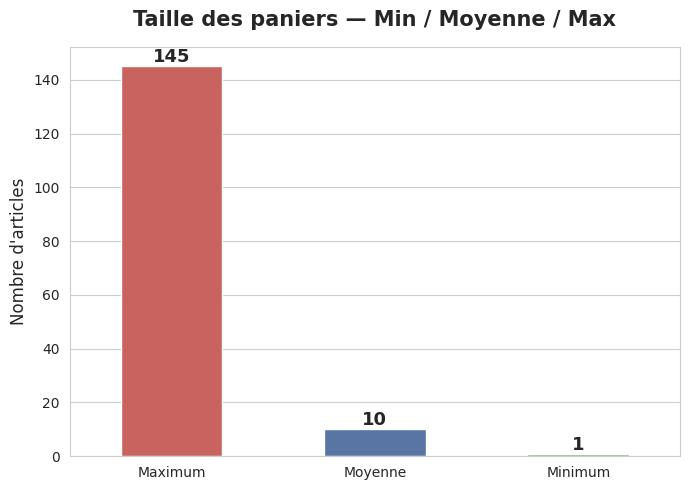

In [43]:
plt.figure(figsize=(7, 5))
sb.set_style("whitegrid")

palette = ["#d9534f", "#4C72B0", "#5cb85c"]  
ax = sb.barplot(x="colonne", y="valeur", data=Result, palette=palette, width=0.5,hue="colonne")

# Valeurs sur les barres
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.title("Taille des paniers — Min / Moyenne / Max", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Nombre d'articles", fontsize=12)
plt.legend([], [], frameon=False)

plt.tight_layout()
plt.show()

## Observations
- En moyenne, un client achète **10 articles** par commande.
- Certaines commandes contiennent jusqu'à **145 articles**, ce qui suggère
  des achats groupés ou des réapprovisionnements importants.
- La distribution est **asymétrique à droite** : certains des paniers
  restent sous 1 articles.

## 8. Le délai depuis la dernière commande influence-t-il le réachat ?

Nous comparons ici le **nombre de jours écoulés** depuis la commande précédente,
selon que le produit a été **racheté ou non**. L'objectif est de détecter
si les clients qui commandent après un long délai ont tendance à explorer
de nouveaux produits plutôt qu'à réacheter les mêmes.

In [44]:
ORDER_DATA_PRODUCT = order_product_dataframe.merge(order_dataframe,on="order_id")
REODERED_AND_DAY_AFTER = ORDER_DATA_PRODUCT[["order_id","product_id","reordered","days_since_prior_order"]].dropna()

Result2 = REODERED_AND_DAY_AFTER.groupby("reordered").agg(
    moyenne_jours = pd.NamedAgg("days_since_prior_order", "mean"),
    median_jours  = pd.NamedAgg("days_since_prior_order", "median"),
).astype(int)
Result2.index = ["Non racheté", "Racheté"]

Result2

REODERED_AND_DAY_AFTER.to_csv("le_delai_depuis_la_commande_influence_le_reachat.csv")

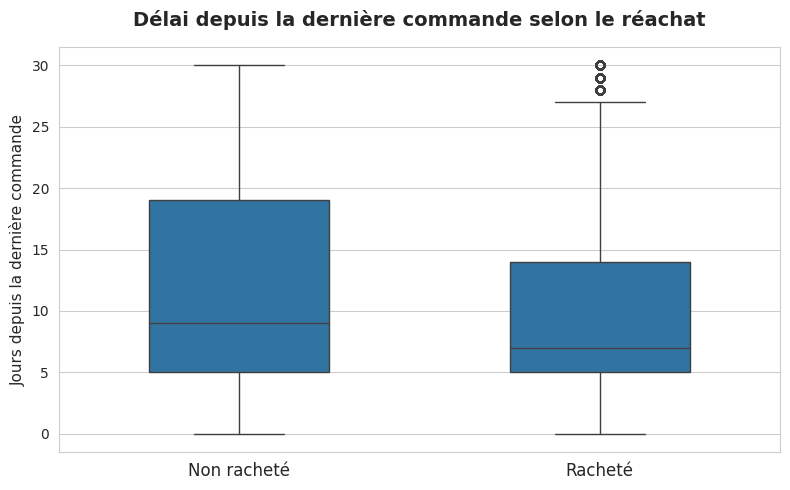

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
sb.set_style("whitegrid")

sb.boxplot(
    x="reordered",
    y="days_since_prior_order",
    data=REODERED_AND_DAY_AFTER,
    width=0.5,
    ax=ax,
)

ax.set_title("Délai depuis la dernière commande selon le réachat",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Jours depuis la dernière commande", fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non racheté", "Racheté"], fontsize=12)

plt.tight_layout()
plt.show()

### Observations
- Les clients qui **rachètent** un produit le font en moyenne après **10 jours**.
- Les clients qui **n'achètent pas** le même produit attendent en moyenne **12 jours**.
- L'écart entre les deux groupes suggère que plus le délai est long,
  moins le client a tendance à réacheter le même produit.